In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

In [3]:
df_l = []
for long_form in used_species:
    df_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi_windowed_annotated.txt".format(long_form)
    s_df = pd.read_csv(df_path, sep="\t")
    s_df["species"] = long_form
    df_l.append(s_df)
all_pi_df = pd.concat(df_l)
all_pi_df = all_pi_df.loc[all_pi_df.species != "Eulemur_mongoz_ssp"].copy()

In [4]:
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_tag = ["chrX" if i == 22 else "aut" for i in range(len(chr_names))]
chr_number = ["chrX" if i == 22 else "chr{}".format(i+1) for i in range(len(chr_names))]
all_pi_df["chr_type"] = all_pi_df.chrom.map(dict(zip(chr_names, chr_tag)))
all_pi_df["NC_chrom"] = all_pi_df.chrom
all_pi_df["chrom"] = all_pi_df.chrom.map(dict(zip(chr_names, chr_number)))
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type,NC_chrom
0,chr1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,NC_060925.1
1,chr1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut,NC_060925.1
2,chr1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,NC_060925.1
3,chr1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut,NC_060925.1
4,chr1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut,NC_060925.1
...,...,...,...,...,...,...,...,...,...,...,...,...
28336,chrX,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX,NC_060947.1
28337,chrX,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX,NC_060947.1
28338,chrX,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX,NC_060947.1
28339,chrX,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX,NC_060947.1


In [5]:
bin_size = 10
all_pi_df["Mb"] = pd.cut(all_pi_df.window_100kb,bins=np.arange(0, all_pi_df.window_100kb.max(), 100000*bin_size), labels=False)
mb1_all_pi_df = all_pi_df.groupby(["species", "chr_type", "chrom", "Mb"])[["pi_window", "mapped_bases"]].sum().reset_index()
mb1_all_pi_df["Pi per mapped base"] = mb1_all_pi_df.pi_window/mb1_all_pi_df.mapped_bases
mb1_all_pi_df = mb1_all_pi_df.loc[mb1_all_pi_df.mapped_bases >= 500000]
mb1_all_pi_df

,species,chr_type,chrom,Mb,pi_window,mapped_bases,Pi per mapped base
0,Allenopithecus_nigroviridis_ssp,aut,chr1,0.0,913.488507,586938,0.001556
1,Allenopithecus_nigroviridis_ssp,aut,chr1,1.0,1115.304917,697579,0.001599
2,Allenopithecus_nigroviridis_ssp,aut,chr1,2.0,1075.406390,648325,0.001659
3,Allenopithecus_nigroviridis_ssp,aut,chr1,3.0,1521.623683,848622,0.001793
4,Allenopithecus_nigroviridis_ssp,aut,chr1,4.0,1768.799993,885713,0.001997
...,...,...,...,...,...,...,...
560189,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,136.0,255.390967,536911,0.000476
560190,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,137.0,81.431367,511262,0.000159
560199,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,146.0,126.351700,632246,0.000200
560201,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,148.0,208.324233,590547,0.000353


In [6]:
recomb_mb1 = pd.read_csv("../data/hs1_1Mb_recomb.txt", sep="\t")
recomb_mb1 = recomb_mb1.rename(columns={"window_1mb": "Mb"})
recomb_mb1["Mb"] = recomb_mb1.Mb/1000000

In [7]:
mb1_pi_recomb = mb1_all_pi_df.merge(recomb_mb1, on=["chrom", "Mb"])
mb1_pi_recomb

,species,chr_type,chrom,Mb,pi_window,mapped_bases_x,Pi per mapped base,cM,mapped_bases_y,cMperMb
0,Allenopithecus_nigroviridis_ssp,chrX,chrX,3.0,1873.056417,752790,0.002488,9.595440e+05,902880,1.062759
1,Allenopithecus_nigroviridis_ssp,chrX,chrX,4.0,1146.252957,876489,0.001308,1.794676e+06,988341,1.815847
2,Allenopithecus_nigroviridis_ssp,chrX,chrX,5.0,3326.607783,886636,0.003752,1.265581e+06,1000913,1.264427
3,Allenopithecus_nigroviridis_ssp,chrX,chrX,6.0,2392.928533,918841,0.002604,1.266264e+06,987708,1.282023
4,Allenopithecus_nigroviridis_ssp,chrX,chrX,7.0,1986.988017,853771,0.002327,1.111387e+06,993747,1.118380
...,...,...,...,...,...,...,...,...,...,...
22090,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,136.0,255.390967,536911,0.000476,3.892399e+05,1001457,0.388674
22091,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,137.0,81.431367,511262,0.000159,2.077129e+06,997334,2.082681
22092,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,146.0,126.351700,632246,0.000200,1.135974e+06,992408,1.144665
22093,Xanthonycticebus_pygmaeus_ssp,chrX,chrX,148.0,208.324233,590547,0.000353,2.193320e+06,989423,2.216767


In [8]:
mb1_all_pi_df["group"] = mb1_all_pi_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
groups = mb1_all_pi_df.groupby(["group", "species", "chrom"])["Pi per mapped base"]
mean, std = groups.transform("mean"), groups.transform("std")
mb1_all_pi_df["pi_norm"] = (mb1_all_pi_df["Pi per mapped base"]/mean)
mb1_all_pi_df["low"] = (mb1_all_pi_df.pi_norm <= 0.5)
mean_low_across_species = mb1_all_pi_df.groupby(["group", "chr_type", "chrom", "Mb"])[["Pi per mapped base", "pi_norm"]].mean().reset_index()
mean_low_across_species["low_count"] = mb1_all_pi_df.groupby(["group", "chr_type", "chrom", "Mb"])[["low"]].sum().reset_index()["low"]
species_counted = mb1_all_pi_df.groupby(["group", "chr_type", "chrom", "Mb"])["pi_norm"].count().reset_index()
mean_low_across_species["species_used"] = species_counted["pi_norm"]
mean_low_across_species["low_proportion"] = mean_low_across_species["low_count"]/mean_low_across_species["species_used"]

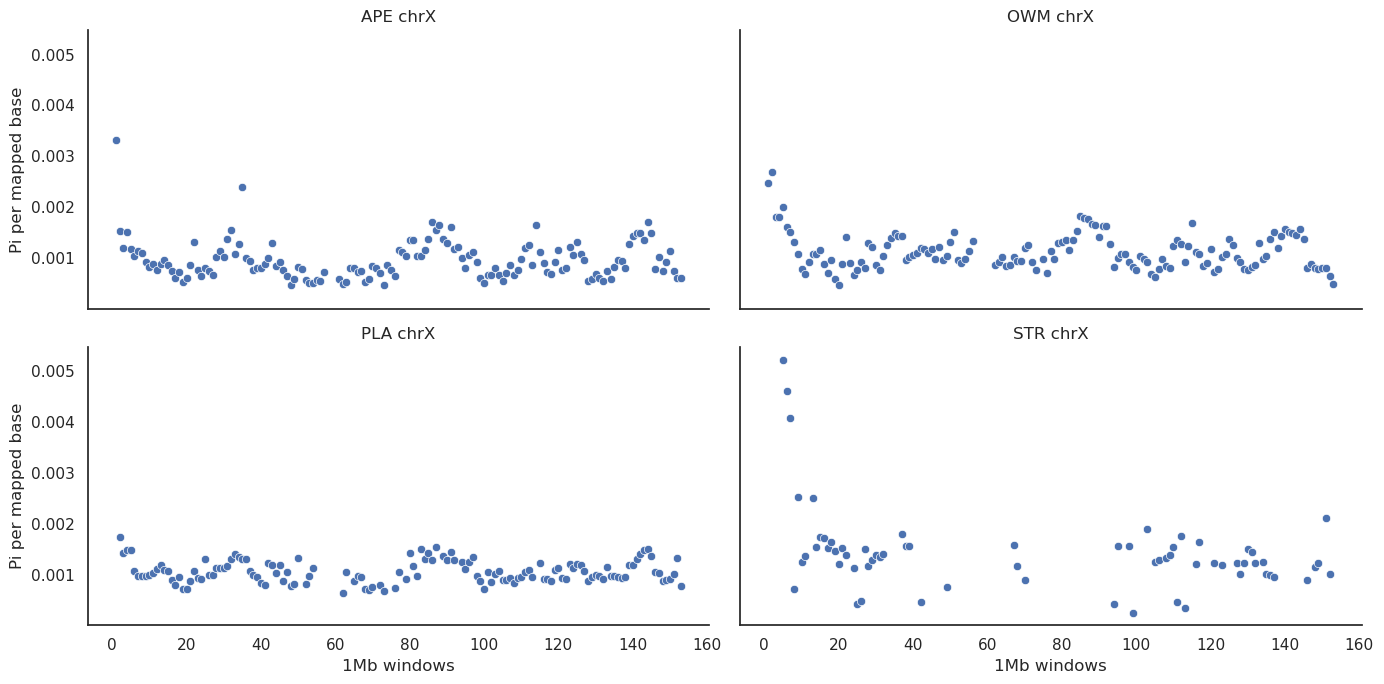

In [9]:
g = sns.FacetGrid(mean_low_across_species.loc[mean_low_across_species.chr_type == "chrX"],
                  col="group", col_wrap=2, height=3.5, aspect=2)
g.map(sns.scatterplot, "Mb", "Pi per mapped base")
g.set_axis_labels("1Mb windows", "Pi per mapped base")
g.set_titles(col_template="{col_name} chrX")

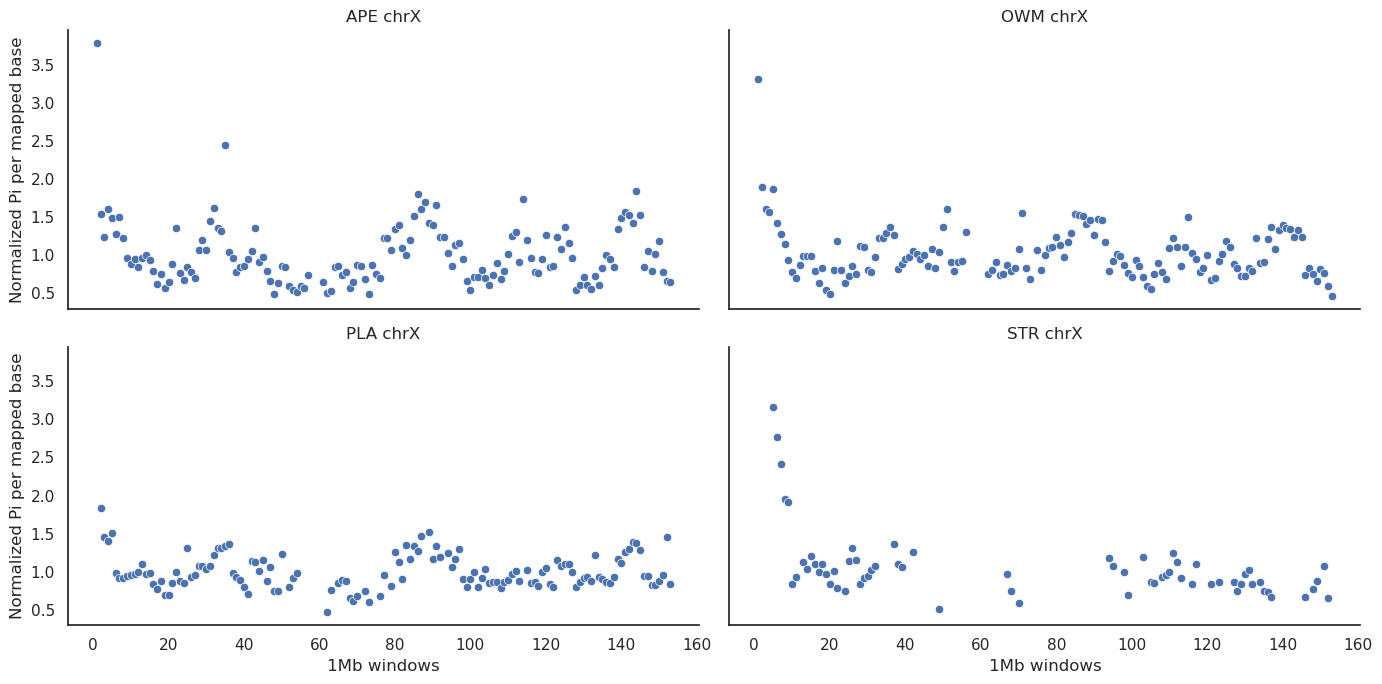

In [10]:
g = sns.FacetGrid(mean_low_across_species.loc[mean_low_across_species.chr_type == "chrX"],
                  col="group", col_wrap=2, height=3.5, aspect=2)
g.map(sns.scatterplot, "Mb", "pi_norm")
g.set_axis_labels("1Mb windows", "Normalized Pi per mapped base")
g.set_titles(col_template="{col_name} chrX")

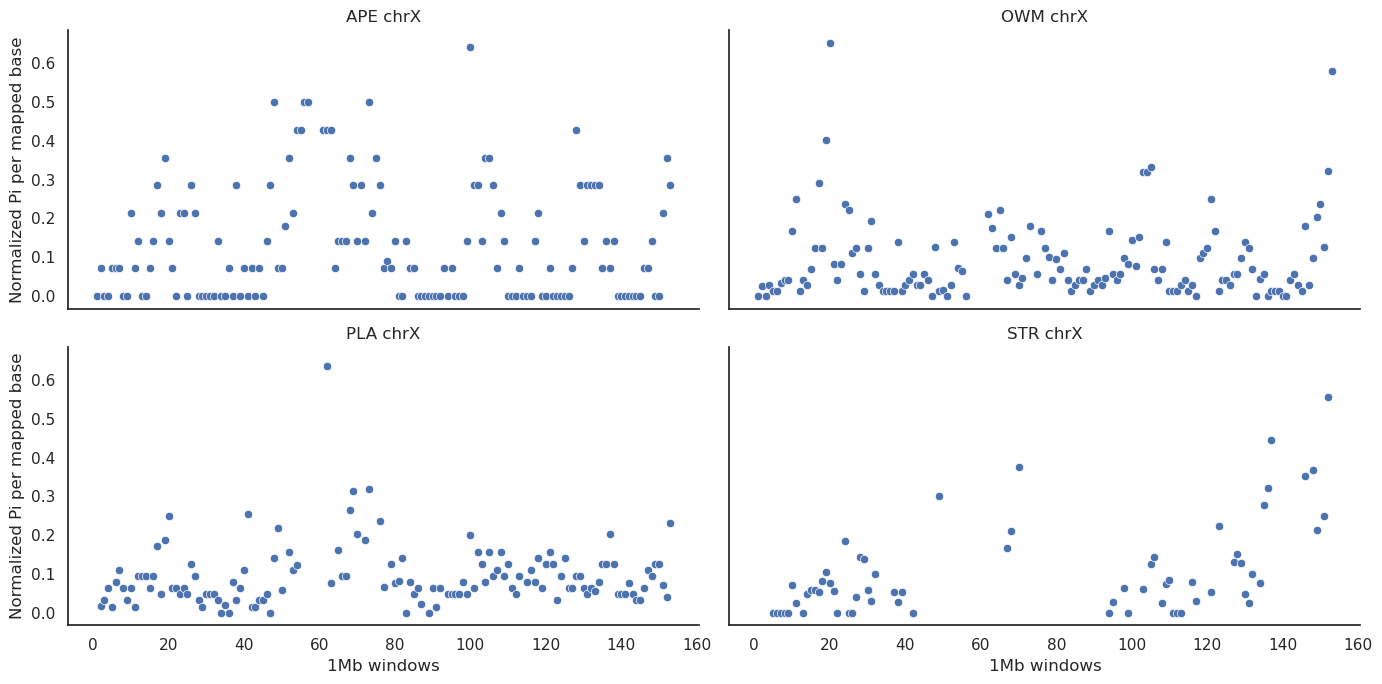

In [11]:
g = sns.FacetGrid(mean_low_across_species.loc[mean_low_across_species.chr_type == "chrX"],
                  col="group", col_wrap=2, height=3.5, aspect=2)
g.map(sns.scatterplot, "Mb", "low_proportion")
g.set_axis_labels("1Mb windows", "Normalized Pi per mapped base")
g.set_titles(col_template="{col_name} chrX")

In [12]:
mean_low_across_species = mean_low_across_species.merge(recomb_mb1, on=["chrom", "Mb"])
mean_low_across_species

,group,chr_type,chrom,Mb,Pi per mapped base,pi_norm,low_count,species_used,low_proportion,cM,mapped_bases,cMperMb
0,APE,chrX,chrX,3.0,0.001198,1.240522,0,14,0.000000,9.595440e+05,902880,1.062759
1,APE,chrX,chrX,4.0,0.001507,1.610725,0,14,0.000000,1.794676e+06,988341,1.815847
2,APE,chrX,chrX,5.0,0.001183,1.491466,1,14,0.071429,1.265581e+06,1000913,1.264427
3,APE,chrX,chrX,6.0,0.001051,1.282726,1,14,0.071429,1.266264e+06,987708,1.282023
4,APE,chrX,chrX,7.0,0.001145,1.501761,1,14,0.071429,1.111387e+06,993747,1.118380
...,...,...,...,...,...,...,...,...,...,...,...,...
489,STR,chrX,chrX,146.0,0.000905,0.665988,12,34,0.352941,1.135974e+06,992408,1.144665
490,STR,chrX,chrX,148.0,0.001157,0.775239,14,38,0.368421,2.193320e+06,989423,2.216767
491,STR,chrX,chrX,149.0,0.001240,0.872058,6,28,0.214286,4.443232e+06,1000504,4.440993
492,STR,chrX,chrX,151.0,0.002110,1.076796,2,8,0.250000,8.177069e+05,998534,0.818907


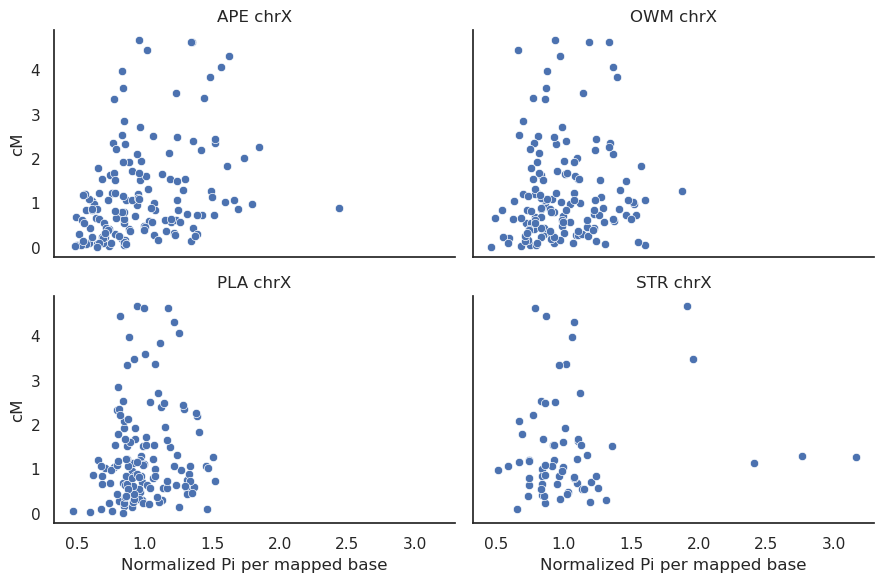

In [13]:

g = sns.FacetGrid(mean_low_across_species.loc[mean_low_across_species.chr_type == "chrX"],
                  col="group", col_wrap=2, height=3, aspect=1.5)
g.map(sns.scatterplot, "pi_norm", "cMperMb")
g.set_axis_labels("Normalized Pi per mapped base", "cM")
g.set_titles(col_template="{col_name} chrX")

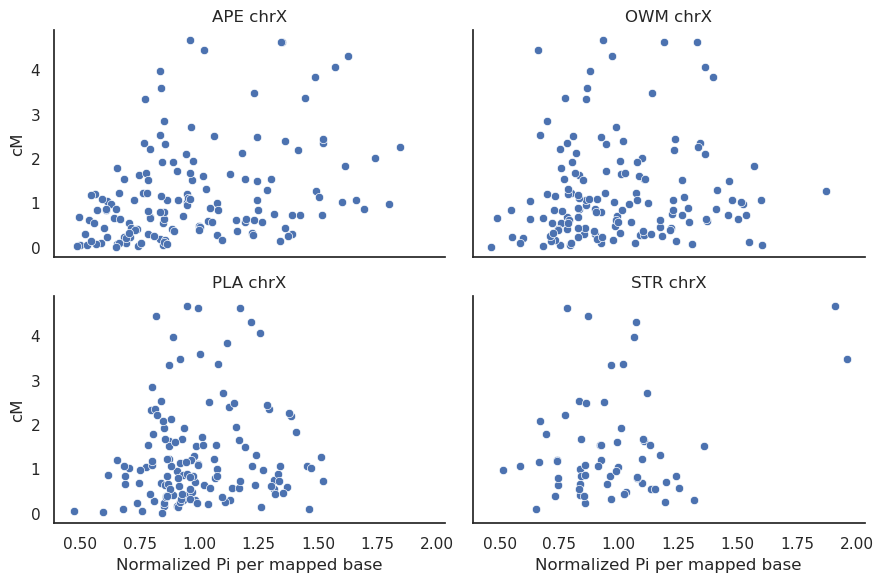

In [14]:
g = sns.FacetGrid(mean_low_across_species.loc[(mean_low_across_species.chr_type == "chrX") &
                                             (mean_low_across_species.pi_norm <= 2)],
                  col="group", col_wrap=2, height=3, aspect=1.5)
g.map(sns.scatterplot, "pi_norm", "cMperMb")
g.set_axis_labels("Normalized Pi per mapped base", "cM")
g.set_titles(col_template="{col_name} chrX")

Strategy version

In [15]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mb1_all_pi_df["binomial_name"] = [x[:-4] for x in mb1_all_pi_df.species]
mb1_all_pi_df["strategy"] = mb1_all_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.consensus)))
groups = mb1_all_pi_df.groupby(["strategy", "species", "chrom"])["Pi per mapped base"]
mean, std = groups.transform("mean"), groups.transform("std")
mb1_all_pi_df["pi_norm"] = (mb1_all_pi_df["Pi per mapped base"]/mean)
mb1_all_pi_df["low"] = (mb1_all_pi_df.pi_norm <= 0.5)
mean_low_across_species = mb1_all_pi_df.groupby(["strategy", "chr_type", "chrom", "Mb"])[["Pi per mapped base", "pi_norm"]].mean().reset_index()
mean_low_across_species["low_count"] = mb1_all_pi_df.groupby(["strategy", "chr_type", "chrom", "Mb"])[["low"]].sum().reset_index()["low"]
species_counted = mb1_all_pi_df.groupby(["strategy", "chr_type", "chrom", "Mb"])["pi_norm"].count().reset_index()
mean_low_across_species["species_used"] = species_counted["pi_norm"]
mean_low_across_species["low_proportion"] = mean_low_across_species["low_count"]/mean_low_across_species["species_used"]
mean_low_across_species = mean_low_across_species.merge(recomb_mb1, on=["chrom", "Mb"])
mean_low_across_species

,strategy,chr_type,chrom,Mb,Pi per mapped base,pi_norm,low_count,species_used,low_proportion,cM,mapped_bases,cMperMb
0,Monogamous,chrX,chrX,3.0,0.001260,1.260966,1,30,0.033333,9.595440e+05,902880,1.062759e+00
1,Monogamous,chrX,chrX,4.0,0.001554,1.544450,1,31,0.032258,1.794676e+06,988341,1.815847e+00
2,Monogamous,chrX,chrX,5.0,0.001449,1.367496,2,32,0.062500,1.265581e+06,1000913,1.264427e+00
3,Monogamous,chrX,chrX,6.0,0.001445,1.215778,1,35,0.028571,1.266264e+06,987708,1.282023e+00
4,Monogamous,chrX,chrX,7.0,0.001130,1.059836,2,32,0.062500,1.111387e+06,993747,1.118380e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
484,Polygynous,chrX,chrX,149.0,0.001164,0.846381,4,41,0.097561,4.443232e+06,1000504,4.440993e+00
485,Polygynous,chrX,chrX,150.0,0.001063,0.953374,7,41,0.170732,2.095597e+06,995034,2.106055e+00
486,Polygynous,chrX,chrX,151.0,0.000962,0.721619,9,42,0.214286,8.177069e+05,998534,8.189075e-01
487,Polygynous,chrX,chrX,152.0,0.000924,0.699847,11,35,0.314286,9.300623e+04,1034066,8.994226e-02


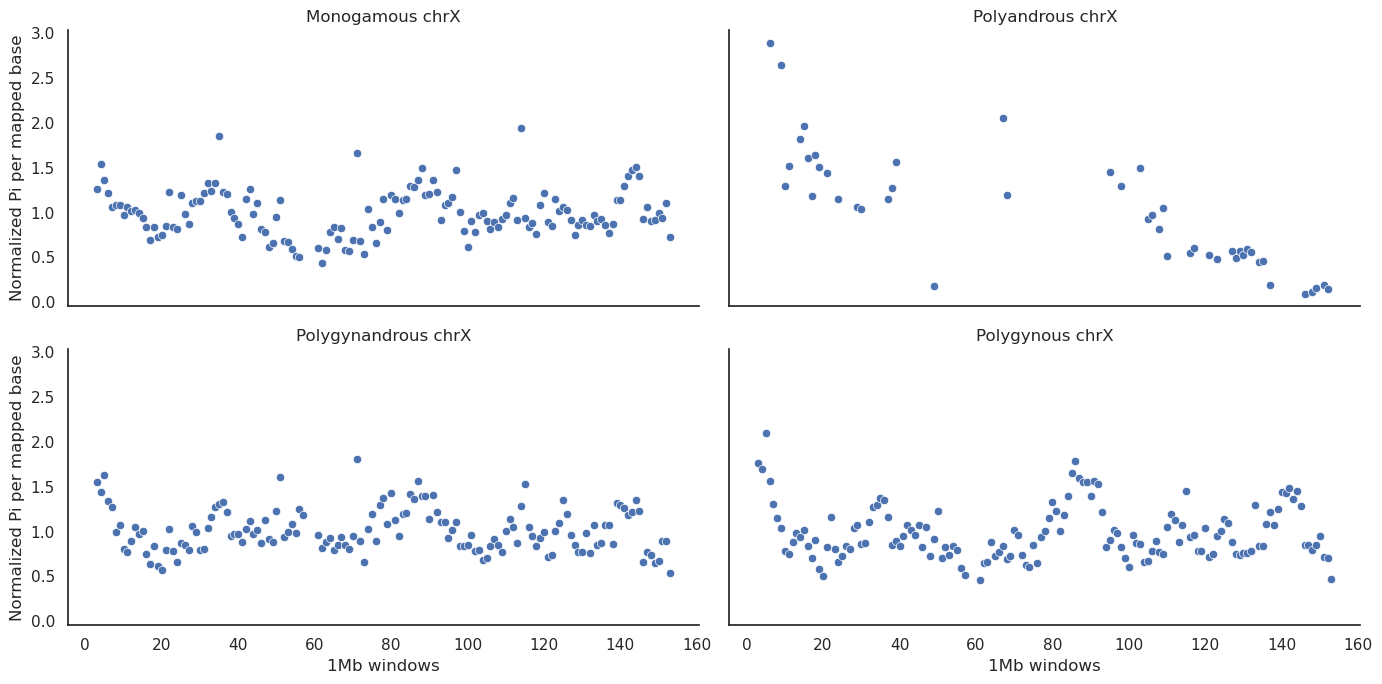

In [16]:
g = sns.FacetGrid(mean_low_across_species.loc[mean_low_across_species.chr_type == "chrX"],
                  col="strategy", col_wrap=2, height=3.5, aspect=2)
g.map(sns.scatterplot, "Mb", "pi_norm")
g.set_axis_labels("1Mb windows", "Normalized Pi per mapped base")
g.set_titles(col_template="{col_name} chrX")

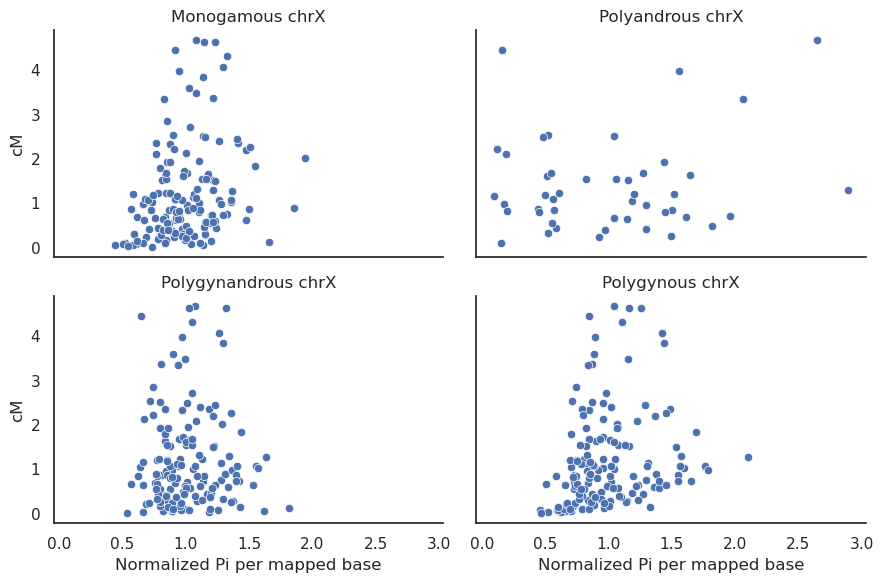

In [17]:
g = sns.FacetGrid(mean_low_across_species.loc[(mean_low_across_species.chr_type == "chrX")],
                  col="strategy", col_wrap=2, height=3, aspect=1.5)
g.map(sns.scatterplot, "pi_norm", "cMperMb")
g.set_axis_labels("Normalized Pi per mapped base", "cM")
g.set_titles(col_template="{col_name} chrX")

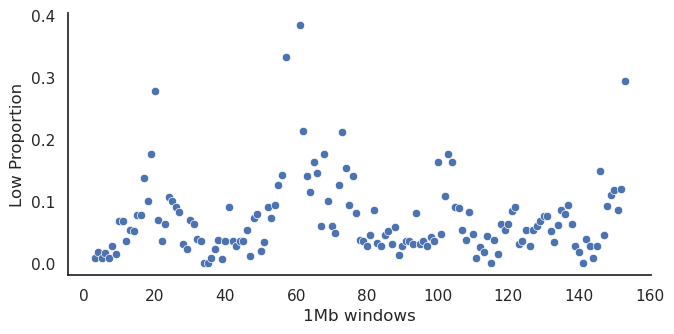

In [18]:
mb1_all_pi_df["binomial_name"] = [x[:-4] for x in mb1_all_pi_df.species]
mb1_all_pi_df["strategy"] = mb1_all_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.consensus)))
groups = mb1_all_pi_df.groupby(["strategy", "species"])["Pi per mapped base"]
mean, std = groups.transform("mean"), groups.transform("std")
mb1_all_pi_df["pi_norm"] = (mb1_all_pi_df["Pi per mapped base"]/mean)
mb1_all_pi_df["low"] = (mb1_all_pi_df.pi_norm <= 0.2)
mean_low_across_species = mb1_all_pi_df.groupby(["strategy", "chr_type", "chrom", "Mb"])[["Pi per mapped base", "pi_norm"]].mean().reset_index()
mean_low_across_species["low_count"] = mb1_all_pi_df.groupby(["strategy", "chr_type", "chrom", "Mb"])[["low"]].sum().reset_index()["low"]
species_counted = mb1_all_pi_df.groupby(["strategy", "chr_type", "chrom", "Mb"])["pi_norm"].count().reset_index()
mean_low_across_species["species_used"] = species_counted["pi_norm"]
mean_low_across_species["low_proportion"] = mean_low_across_species["low_count"]/mean_low_across_species["species_used"]
mean_low_across_species = mean_low_across_species.merge(recomb_mb1, on=["chrom", "Mb"])

all_sum = mean_low_across_species.groupby(["chr_type", "chrom", "Mb"])[["low_count", "species_used"]].sum().reset_index()
all_sum["Low Proportion"] = all_sum.low_count/all_sum.species_used
g = sns.FacetGrid(all_sum.loc[all_sum.chr_type == "chrX"], height=3.5, aspect=2)
g.map(sns.scatterplot, "Mb", "Low Proportion")
g.set_axis_labels("1Mb windows", "Low Proportion")
g.set_titles(col_template="{col_name} chrX")